### Dataset attribute descriptions

**CustomerID**: A unique ID that identifies each customer.

**Count**: A value used in reporting/dashboarding to sum up the number of customers in a filtered set.

**Country**: The country of the customer’s primary residence.

**State**: The state of the customer’s primary residence.

**City**: The city of the customer’s primary residence.

**Zip Code**: The zip code of the customer’s primary residence.

**Lat Long**: The combined latitude and longitude of the customer’s primary residence.

**Latitude**: The latitude of the customer’s primary residence.

**Longitude**: The longitude of the customer’s primary residence.

**Gender**: The customer’s gender: Male, Female

**Senior Citizen**: Indicates if the customer is 65 or older: Yes, No

**Partner**: Indicate if the customer has a partner: Yes, No

**Dependents**: Indicates if the customer lives with any dependents: Yes, No. Dependents could be children, parents, grandparents, etc.

**Tenure Months**: Indicates the total amount of months that the customer has been with the company by the end of the quarter specified above.

**Phone Service**: Indicates if the customer subscribes to home phone service with the company: Yes, No

**Multiple Lines**: Indicates if the customer subscribes to multiple telephone lines with the company: Yes, No

**Internet Service**: Indicates if the customer subscribes to Internet service with the company: No, DSL, Fiber Optic, Cable.

**Online Security**: Indicates if the customer subscribes to an additional online security service provided by the company: Yes, No

**Online Backup**: Indicates if the customer subscribes to an additional online backup service provided by the company: Yes, No

**Device Protection**: Indicates if the customer subscribes to an additional device protection plan for their Internet equipment provided by the company: Yes, No

**Tech Support**: Indicates if the customer subscribes to an additional technical support plan from the company with reduced wait times: Yes, No

**Streaming TV**: Indicates if the customer uses their Internet service to stream television programing from a third party provider: Yes, No. The company does not charge an additional fee for this service.

**Streaming Movies**: Indicates if the customer uses their Internet service to stream movies from a third party provider: Yes, No. The company does not charge an additional fee for this service.

**Contract**: Indicates the customer’s current contract type: Month-to-Month, One Year, Two Year.

**Paperless Billing**: Indicates if the customer has chosen paperless billing: Yes, No

**Payment Method**: Indicates how the customer pays their bill: Bank Withdrawal, Credit Card, Mailed Check

**Monthly Charge**: Indicates the customer’s current total monthly charge for all their services from the company.

**Total Charges**: Indicates the customer’s total charges, calculated to the end of the quarter specified above.

**Churn Label**: Yes = the customer left the company this quarter. No = the customer remained with the company. Directly related to Churn Value.

**Churn Value**: 1 = the customer left the company this quarter. 0 = the customer remained with the company. Directly related to Churn Label.

**Churn Score**: A value from 0-100 that is calculated using the predictive tool IBM SPSS Modeler. The model incorporates multiple factors known to cause churn. The higher the score, the more likely the customer will churn.

**CLTV**: Customer Lifetime Value. A predicted CLTV is calculated using corporate formulas and existing data. The higher the value, the more valuable the customer. High value customers should be monitored for churn.

**Churn Reason**: A customer’s specific reason for leaving the company. Directly related to Churn Category.

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("../data/Telco_Customer_Churn.xlsx")

In [63]:
print(f"Number of columns: {df.shape[1]}\n") # amount of cols
df.info() # amount of rows, columns and data types
df.describe() # statistical summary of numerical columns

Number of columns: 33

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  I

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [64]:
# Lower each column name
df.columns = df.columns.str.lower()

In [65]:
# Gender distribution
"""
male = df[df["Gender"]=="Male"]
female = df[df["Gender"]=="Female"]

male_count = male.shape[0]
female_count = female.shape[0]
total_count = df.shape[0]

male_churn_count = male[male["Churn Value"] == 1].shape[0]
female_churn_count = female[female["Churn Value"] == 1].shape[0]

churn_by_gender = pd.DataFrame({
    "Gender" : ["Male", "Male", "Female", "Female"],
    "Churn Status" : ["Churned", "Not Churned", "Churned", "Not Churned"],
    "Count" : [male_churn_count, male_count - male_churn_count, female_churn_count, female_count - female_churn_count]
})
"""

gender_summary = pd.crosstab(
    df["gender"],
    df["churn value"].map({1: "churned", 0: "not churned"}),
    margins=True, # automatically calculates total
    margins_name="total"
)

print(gender_summary)

churn value  churned  not churned  total
gender                                  
Female           939         2549   3488
Male             930         2625   3555
total           1869         5174   7043


In [66]:
# Contract Type
churn_by_contract = df["contract"].value_counts().reset_index(name = "churn count")

print(churn_by_contract.to_string(index=False))

      contract  churn count
Month-to-month         3875
      Two year         1695
      One year         1473


In [70]:
# Distribution of Churn Reason
churn_with_reason = df["churn reason"].value_counts()
#print(churn_with_reason)
                                                  
# Churn Without Reason Provided
churn_without_reason = df[(df["churn reason"] == None) & (df["churn value"] == 1)].shape[0]      

print(f"\nChurn with a reason given: {churn_with_reason.sum()}")
print(f"Churn without reason: {churn_without_reason}")                                    


def churn_reason_count(churn_reason: list[str]) -> int:
    return sum(churn_with_reason[reason] for reason in churn_reason)


churn_reasons: dict[str, list[str]] = {
    "Competitor" : ["Competitor offered higher download speeds", "Competitor offered more data", "Competitor made better offer", "Competitor had better devices"],
    "Service" : ["Network reliability", "Limited range of services"],
    "Pricing" : ["Price too high", "Extra data charges", "Long distance charges", "Lack of affordable download/upload speed"],
    "Customer Support" : ["Attitude of support person", "Attitude of service provider", "Lack of self-service on Website", "Poor expertise of phone support", "Poor expertise of online support"],
    "Personal" : ["Service dissatisfaction", "Moved", "Deceased"],
    "Miscellaneous" : ["Don't know"]
}

churn_category_count: dict[str, int] = {
    category : churn_reason_count(reasons) for category, reasons in churn_reasons.items()
}

for reason, count in churn_category_count.items():
    print(f"Churn because of {reason} reason: {count}")


Churn with a reason given: 1869
Churn without reason: 0
Churn because of Competitor reason: 621
Churn because of Service reason: 147
Churn because of Pricing reason: 243
Churn because of Customer Support reason: 454
Churn because of Personal reason: 148
Churn because of Miscellaneous reason: 154


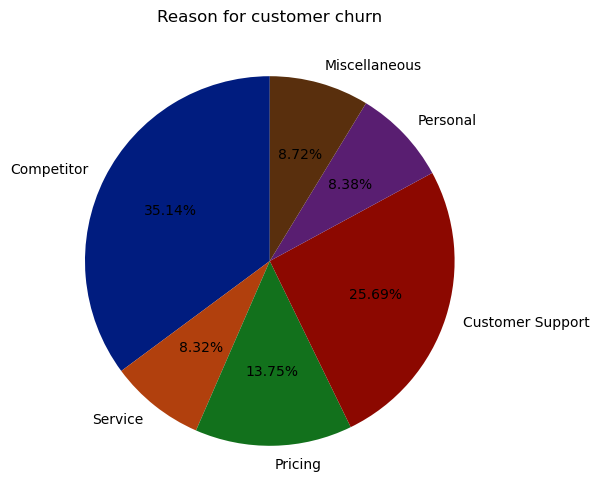

In [71]:
labels = list(churn_category_count.keys())
data = list(churn_category_count.values())

plt.figure(figsize=(10,6))
colors = sns.color_palette("dark")

plt.pie(data, labels=labels, colors=colors, autopct="%.2f%%", startangle=90) # start at north
plt.title("Reason for customer churn")

plt.show()

In [98]:
location_count = df["city"].value_counts().reset_index(name="counts")
churn_by_location = df[df["churn value"] == 1].groupby("city")["churn value"].sum().reset_index(name="churn count")
location_summary = location_count.merge(churn_by_location, on = "city").assign(churn_percentage = lambda df: round(100 * df["churn count"] / df["counts"],2))
print(location_summary.to_string(index=False))

                  city  counts  churn count  churn_percentage
           Los Angeles     305           90             29.51
             San Diego     150           50             33.33
              San Jose     112           29             25.89
            Sacramento     108           26             24.07
         San Francisco     104           31             29.81
                Fresno      64           16             25.00
            Long Beach      60           15             25.00
               Oakland      52           13             25.00
              Stockton      44           12             27.27
           Bakersfield      40            3              7.50
              Glendale      40           13             32.50
             Riverside      32            8             25.00
              Berkeley      32            9             28.12
              Whittier      30            5             16.67
              Pasadena      30            9             30.00
        